# ChordCutter Bot


## Dataset

[Music Bench](https://huggingface.co/datasets/amaai-lab/MusicBench)

## Idea

<strong>Input</strong>: audio file

<strong>Output</strong>: chord sheet

1. Input audio file
2. Audio file gets split into segments (ex: 10s)
3. Each segment gets passed into the NN. Outputs the chord progression and the timestamp
4. Pass the same segment into another NN that generates the lyrics and timestamps
5. Overlay the chords and lyrics based on the timestamps

### Components

1. Audio to chords NN
2. Audio to lyrics NN
3. Chord sheet assembler
4. Data preprocessor (ex: .mp3 to .wav?)

### TODO

- Mess around with stuff
- Send IT a request for high computer computers so we can load the data (cc Venture)
- Research data preprocessing --> what transformations, data representations, etc. would be useful?


In [1]:
# Libraries
import os
import torch
import requests
import tarfile
import librosa
from io import BytesIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from datasets import load_dataset

/Users/seannguyen/GitHub/ChordCutterBot/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("amaai-lab/MusicBench")
ds

DatasetDict({
    train: Dataset({
        features: ['dataset', 'location', 'main_caption', 'alt_caption', 'prompt_aug', 'prompt_ch', 'prompt_bt', 'prompt_bpm', 'prompt_key', 'beats', 'bpm', 'chords', 'chords_time', 'key', 'keyprob', 'is_audioset_eval_mcaps'],
        num_rows: 52768
    })
    test: Dataset({
        features: ['dataset', 'location', 'main_caption', 'alt_caption', 'prompt_aug', 'prompt_ch', 'prompt_bt', 'prompt_bpm', 'prompt_key', 'beats', 'bpm', 'chords', 'chords_time', 'key', 'keyprob', 'is_audioset_eval_mcaps'],
        num_rows: 800
    })
})

In [3]:
train_df = ds['train'].to_pandas()
test_df = ds['test'].to_pandas()

train_df
# test_df

,dataset,location,main_caption,alt_caption,prompt_aug,prompt_ch,prompt_bt,prompt_bpm,prompt_key,beats,bpm,chords,chords_time,key,keyprob,is_audioset_eval_mcaps
0,MusicBench,data_aug2/-0SdAVK79lg_1.wav,This mellow instrumental track showcases a dom...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat counts to 4.,The bpm is 112.0.,The key of this song is E major.,"[[0.37212133669135816, 0.9070457581851855, 1.4...",112.0,[E],[0.5400400339790407],"[E, major]",[0.8934084177017212],False
1,MusicBench,data_aug2/-0SdAVK79lg_2.wav,This relaxing song is perfect for a coffee sho...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat is 4.,The song is played at the pace of Vivace.,This song is in the key of E major.,"[[0.2658142022146419, 0.6479221178981897, 1.04...",157.0,[E],[0.4485947212378337],"[E, major]",[0.8934084177017212],False
2,MusicBench,data_aug2/-0SdAVK79lg_3.wav,This laid-back instrumental track is perfect f...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat counts to 4.,The bpm is 151.0.,The key of this song is E major.,"[[0.2754422138603508, 0.6713903962846051, 1.08...",151.0,[E],[0.3861310098244245],"[E, major]",[0.8934084177017212],False
3,MusicBench,data_aug2/-0SdAVK79lg_4.wav,This is a relaxing song that features an elect...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat is 4.,The song is played at the pace of Vivace.,This song is in the key of E major.,"[[0.2801938173601484, 0.6829724298153618, 1.10...",148.0,[E],[0.33809850513698275],"[E, major]",[0.8934084177017212],False
4,MusicBench,data_aug2/-0SdAVK79lg_5.wav,This relaxing song is perfect for a coffee sho...,This song features an electric guitar as the m...,,The chord sequence is C#.,The time signature is 4/4.,This song goes at 130.0 beats per minute.,This song is in the key of C# major.,"[[0.32, 0.78, 1.26, 1.74, 2.2, 2.66, 3.12, 3.5...",130.0,[C#],[0.33809850513698275],"[C#, major]",[0.8934084177017212],False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52763,MusicBench,data/zir3uL14ijM.wav,This mellow tune is led by a passionate male v...,The low quality recording features a passionat...,,"The chord progression in this song is E, F#m7,...",The beat is 3.,The bpm is 92.0.,This song is in the key of E major.,"[[0.02, 0.68, 1.38, 2.0, 2.66, 3.3, 3.96, 4.58...",92.0,"[E, F#m7, F#m7b5, E/B]","[0.464399092, 1.30031746, 3.90095238, 6.315827...","[E, major]",[0.8000931739807129],False
52764,MusicBench,data/zjZV0tvur2I.wav,"This song, in the key of G minor and with a te...",The low quality recording features a widely sp...,,The chord sequence is Ab7.,The beat counts to 2.,The tempo of this song is 127.0 beats per minute.,This song is in the key of G minor.,"[[0.28, 0.76, 1.22, 1.72, 2.2, 2.66, 3.16, 3.6...",127.0,[Ab7],[1.30031746],"[G, minor]",[0.7355943918228149],False
52765,MusicBench,data/zjsWFvUkh7M.wav,This Pop Rock song is led by a lively male voc...,A male vocalist sings this energetic song. The...,,"The chord sequence is D, Gm, Daug.",The beat is 3.,This song goes at 110.0 beats per minute.,The key of this song is D minor.,"[[0.02, 0.54, 1.06, 1.58, 2.12, 2.64, 3.18, 3....",110.0,"[D, Gm, Daug]","[0.557278911, 3.622312925, 8.266303854]","[D, minor]",[0.7975711822509766],True
52766,MusicBench,data/zqbHYVH6Wqo.wav,This devotional and spirited instrumental song...,The song is an instrumental. The tempo is medi...,,The chord sequence is F.,The beat is 2.,This song is played in Presto.,The key is F major.,"[[0.28, 0.6, 0.94, 1.28, 1.64, 1.98, 2.32, 2.6...",177.0,[F],[0.464399092],"[F, major]",[0.8479340076446533],False


In [4]:
def open_audio_file(location='', num=-1):
    ''' 
    Gets the tar file online without reading everything into memory. Iterates through response one file at a time.
    Only considers files (and currently .wav files). Can be used to get a specific file, though this is achieved
    by iterating over every item in the decompressed tar file. Can also be used to get a specific number of files.

    Input
    - location: the filepath (as provided by the "Location" column in the dataset) to retrieve (note: current implementation is very inefficient). Default is the empty string, which will output all files
    - num: the number of files to retrieve, from the beginning. Default is -1, which will output all the files

    Output
    - None
    '''
    url = 'https://huggingface.co/datasets/amaai-lab/MusicBench/resolve/main/MusicBench.tar.gz'
    response = requests.get(url, stream=True)
    print("response received!")
    print(response, '\n')
    retrieved_count = 0
    
    if response.status_code == 200:
        # open tar file as a stream
        with tarfile.open(fileobj=response.raw, mode='r|gz') as tar:
            print("opened tar file!")

            for member in tar:
                # only care about files
                # if location is given, only get that file; otherwise get all files
                if member.isfile() and (member.name == f"datashare/{location}" or not location):
                    file = tar.extractfile(member)
                    print("Type:", type(file))
                    print("File:", file)
                    print(f"File name: {member.name}")

                    file = tar.extractfile(member)
                    print("Extracted file:", file, '\n')

                    # read this file into memory
                    file_bytes = BytesIO(file.read())

                    # only get audio files
                    if member.name.endswith('.wav'):
                        audio_data, sr = librosa.load(file_bytes, sr=None)

                        # metadata
                        print("-----METADATA-----")
                        print(f"Audio length: {len(audio_data)} samples, Sample Rate: {sr}")
                        print(type(audio_data), audio_data.shape)
                        print("audio_data element:", audio_data[0])

                        # sound amplitude
                        plt.plot(audio_data)
                        plt.show()

                        # Mel-frequency cepstral coefficients
                        mfccs = librosa.feature.mfcc(y=audio_data, sr=sr, n_mfcc=13)
                        print("MFCCs:", mfccs.shape)

                        # chroma feature extraction
                        chroma = librosa.feature.chroma_stft(y=audio_data, sr=sr)
                        plt.figure(figsize=(10, 4))
                        librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', cmap='coolwarm', sr=sr)
                        plt.colorbar(label='Intensity')
                        plt.title('Chroma Feature Representation')
                        plt.xlabel('Time (seconds)')
                        plt.ylabel('Pitch Class')
                        plt.show()

                    file.close()
                    if location:  # stop after finding requested file
                        break
                    else:
                        retrieved_count += 1
                        if retrieved_count == num:
                            break
    else:
        print(f"Failed to download the file: {response.status_code}")

response received!
<Response [200]> 

opened tar file!
Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/u3yOMK8SuRI_1.wav'>
File name: datashare/data_aug2/u3yOMK8SuRI_1.wav
Extracted file: <ExFileObject name='datashare/data_aug2/u3yOMK8SuRI_1.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.0


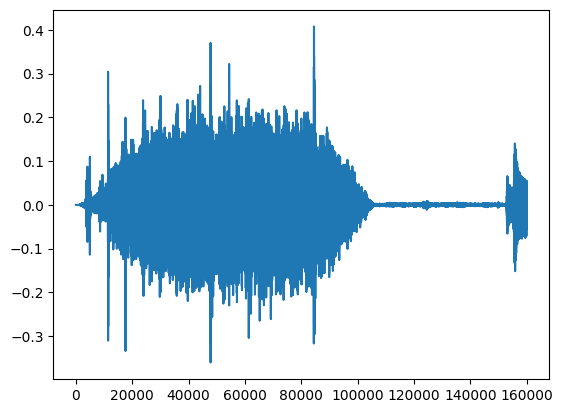

MFCCs: (13, 313)


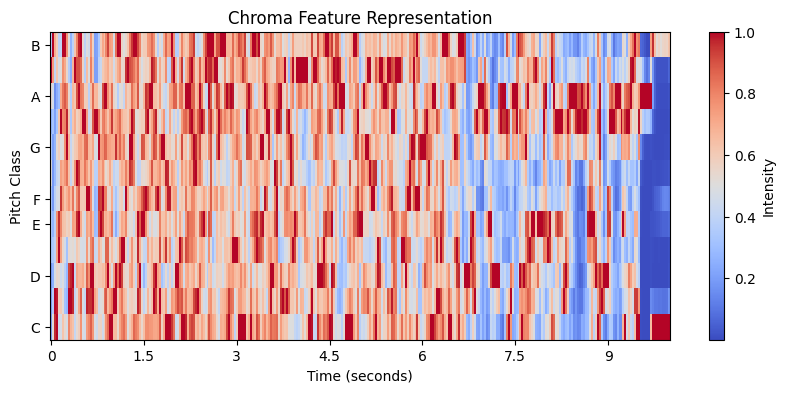

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/4a1a-lmDVaY_11.wav'>
File name: datashare/data_aug2/4a1a-lmDVaY_11.wav
Extracted file: <ExFileObject name='datashare/data_aug2/4a1a-lmDVaY_11.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.0024597168


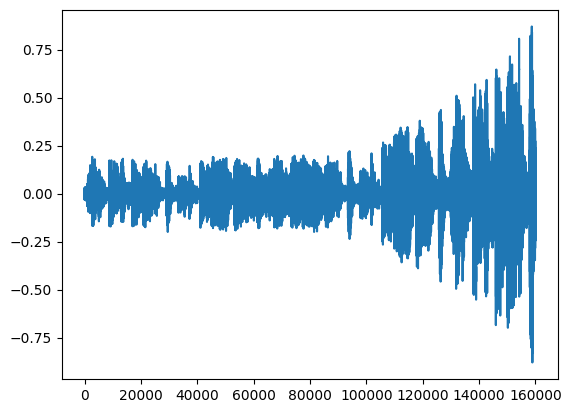

MFCCs: (13, 313)


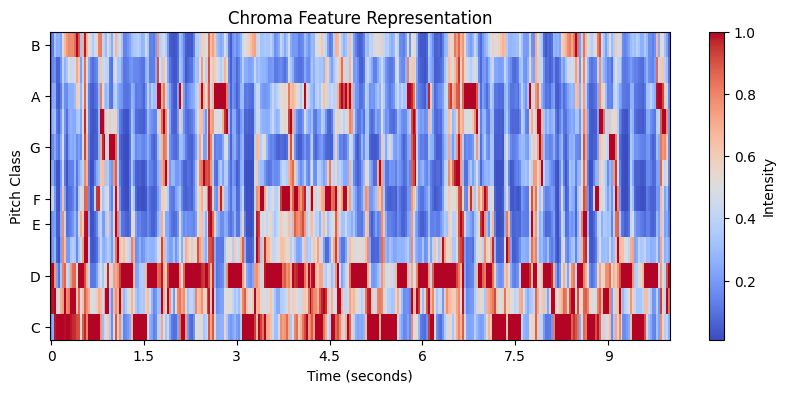

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/rE7S4nLrThs_5.wav'>
File name: datashare/data_aug2/rE7S4nLrThs_5.wav
Extracted file: <ExFileObject name='datashare/data_aug2/rE7S4nLrThs_5.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: -0.031066895


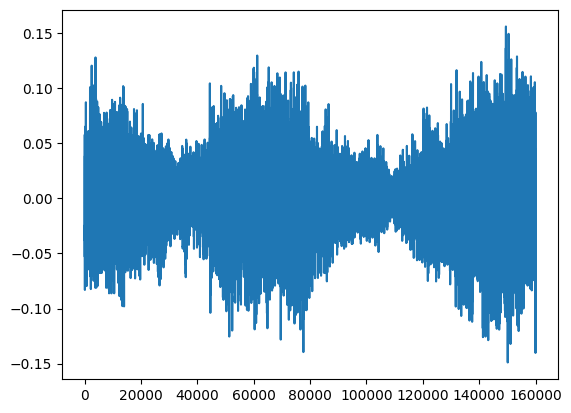

MFCCs: (13, 313)


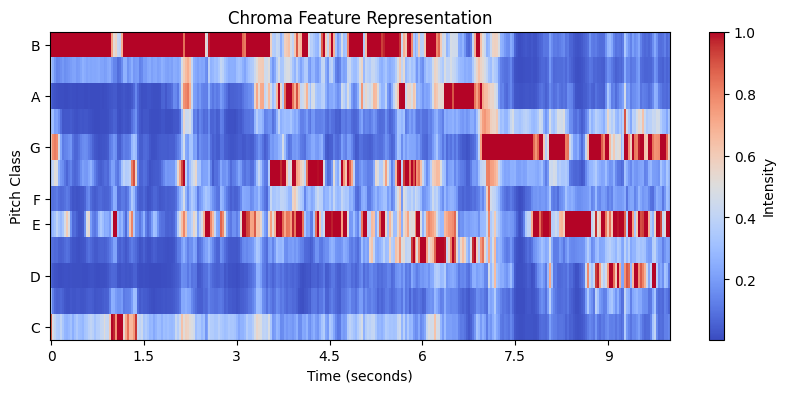

In [7]:
# get specific number of audio files
open_audio_file(num=3)

response received!
<Response [200]> 

opened tar file!
Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/u3yOMK8SuRI_1.wav'>
File name: datashare/data_aug2/u3yOMK8SuRI_1.wav
Extracted file: <ExFileObject name='datashare/data_aug2/u3yOMK8SuRI_1.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.0


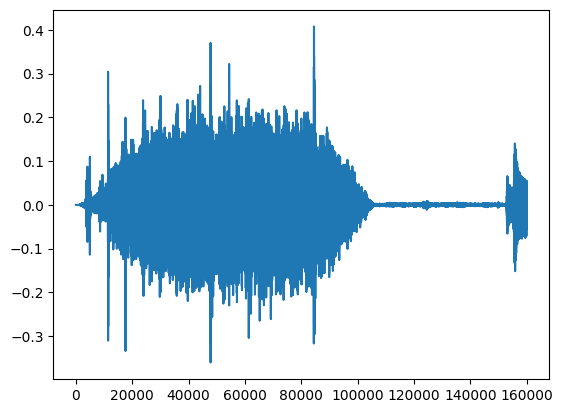

MFCCs: (13, 313)


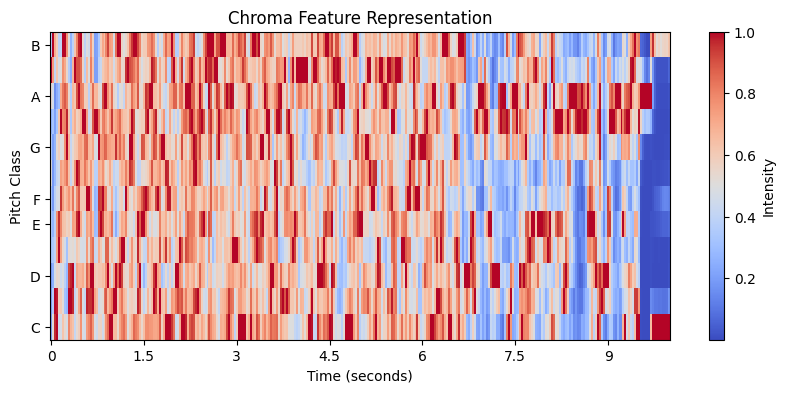

In [6]:
# get audio file by location (see table)
open_audio_file("data_aug2/u3yOMK8SuRI_1.wav")

response received!
<Response [200]> 

opened tar file!
Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/u3yOMK8SuRI_1.wav'>
File name: datashare/data_aug2/u3yOMK8SuRI_1.wav
Extracted file: <ExFileObject name='datashare/data_aug2/u3yOMK8SuRI_1.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.0


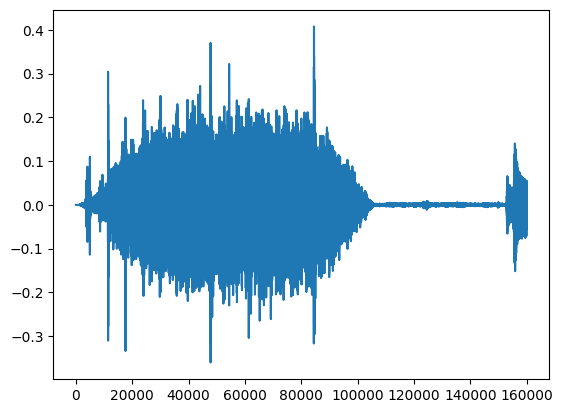

MFCCs: (13, 313)


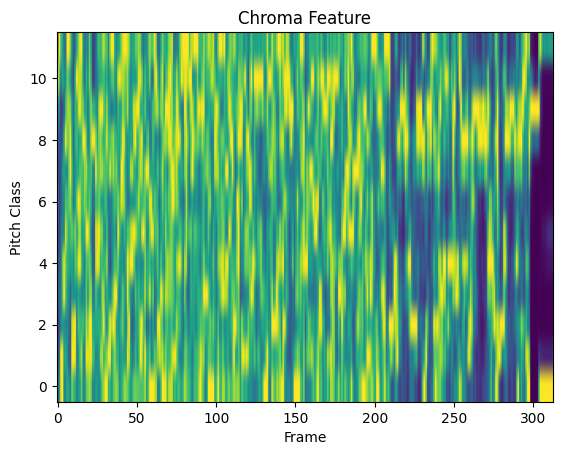

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/4a1a-lmDVaY_11.wav'>
File name: datashare/data_aug2/4a1a-lmDVaY_11.wav
Extracted file: <ExFileObject name='datashare/data_aug2/4a1a-lmDVaY_11.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.0024597168


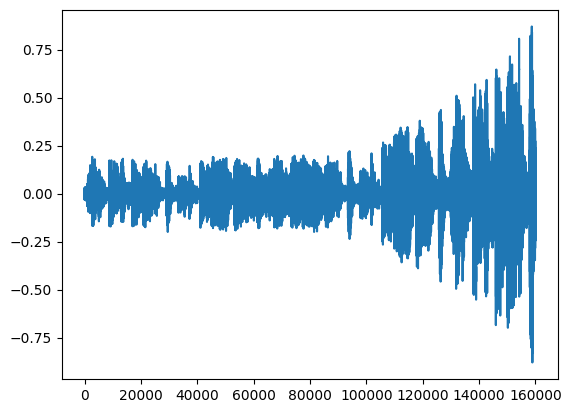

MFCCs: (13, 313)


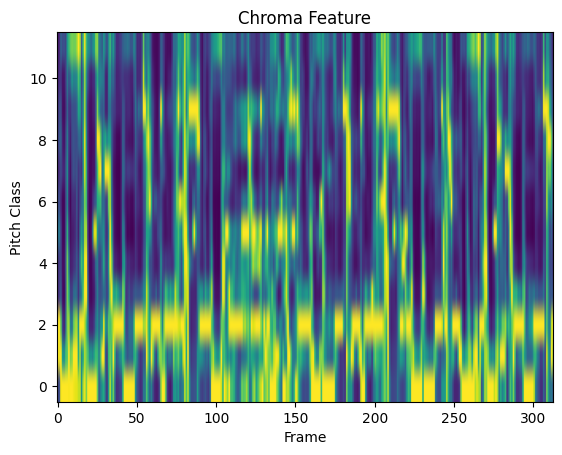

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/rE7S4nLrThs_5.wav'>
File name: datashare/data_aug2/rE7S4nLrThs_5.wav
Extracted file: <ExFileObject name='datashare/data_aug2/rE7S4nLrThs_5.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: -0.031066895


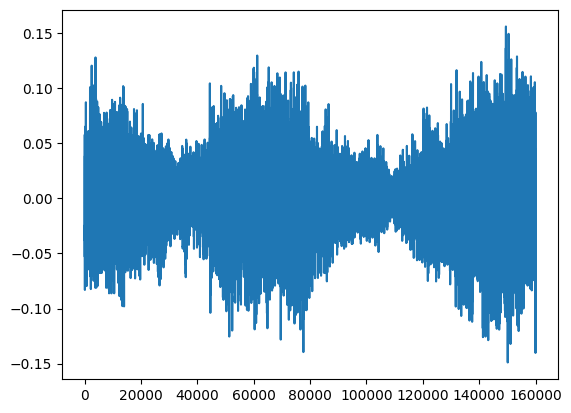

MFCCs: (13, 313)


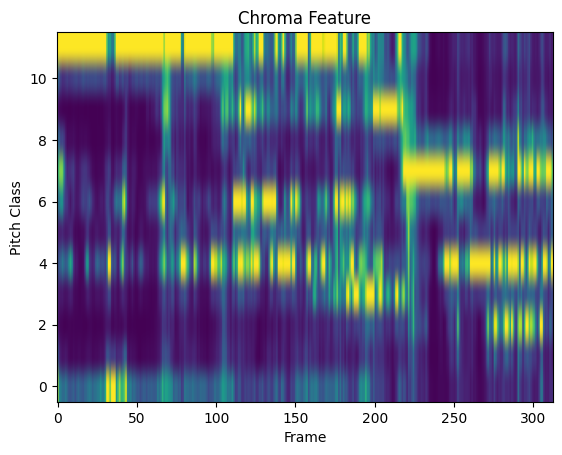

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/RneRJ5ZnHlE_2.wav'>
File name: datashare/data_aug2/RneRJ5ZnHlE_2.wav
Extracted file: <ExFileObject name='datashare/data_aug2/RneRJ5ZnHlE_2.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.06460571


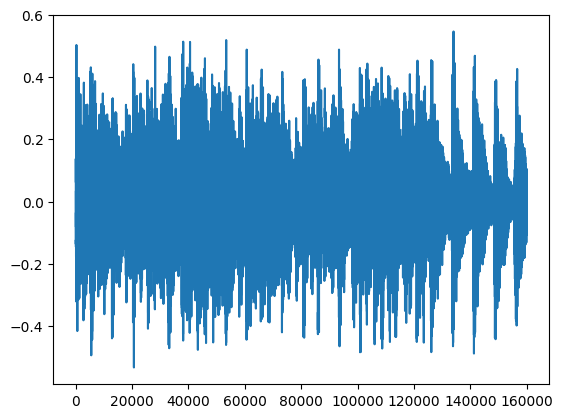

MFCCs: (13, 313)


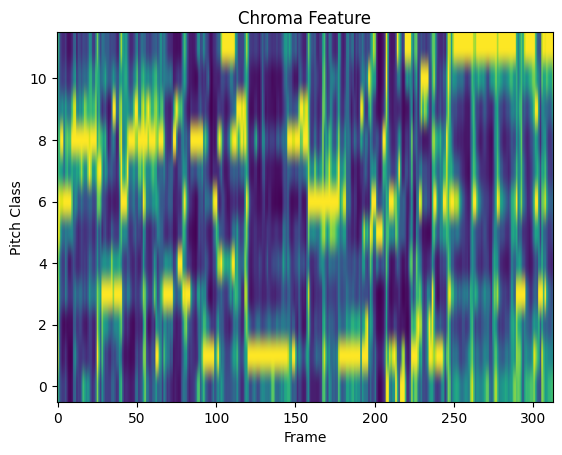

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/Wu-Oh9OJIlI_9.wav'>
File name: datashare/data_aug2/Wu-Oh9OJIlI_9.wav
Extracted file: <ExFileObject name='datashare/data_aug2/Wu-Oh9OJIlI_9.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.24996948


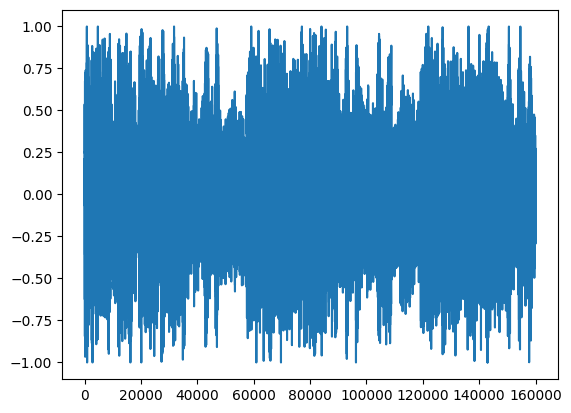

MFCCs: (13, 313)


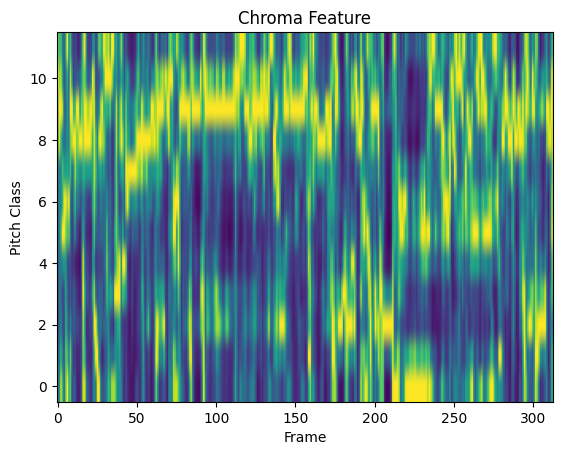

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/z8Wjdss5uMg_1.wav'>
File name: datashare/data_aug2/z8Wjdss5uMg_1.wav
Extracted file: <ExFileObject name='datashare/data_aug2/z8Wjdss5uMg_1.wav'> 

-----METADATA-----
Audio length: 138022 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (138022,)
audio_data element: -6.1035156e-05


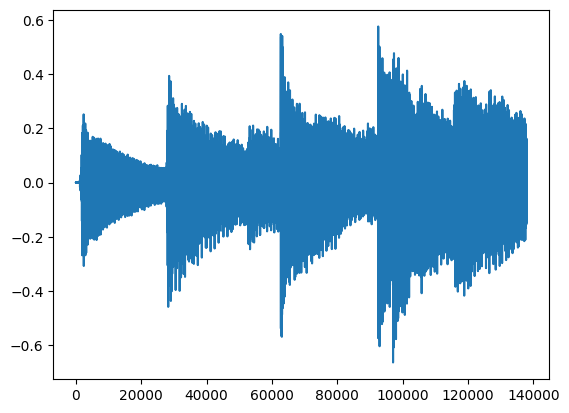

MFCCs: (13, 270)


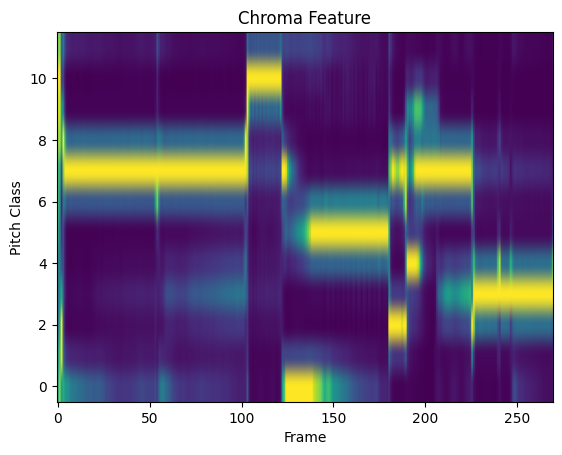

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/IlUcHzBzZvg_10.wav'>
File name: datashare/data_aug2/IlUcHzBzZvg_10.wav
Extracted file: <ExFileObject name='datashare/data_aug2/IlUcHzBzZvg_10.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.08459473


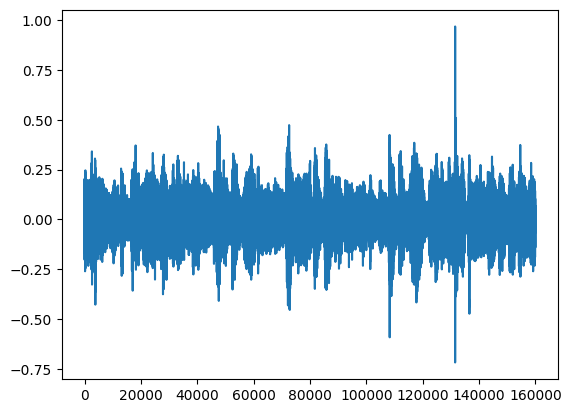

MFCCs: (13, 313)


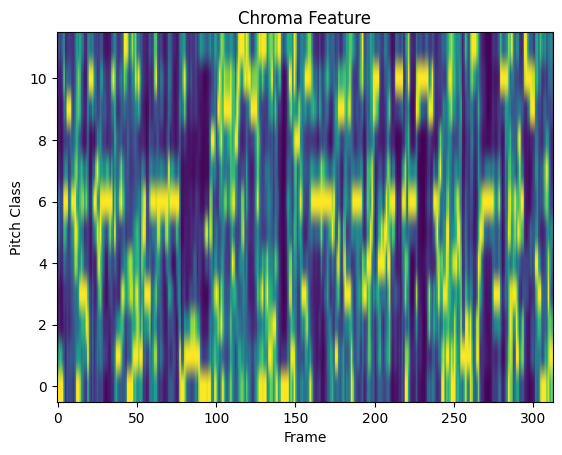

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/BXo1Tr_oJds_6.wav'>
File name: datashare/data_aug2/BXo1Tr_oJds_6.wav
Extracted file: <ExFileObject name='datashare/data_aug2/BXo1Tr_oJds_6.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.05041504


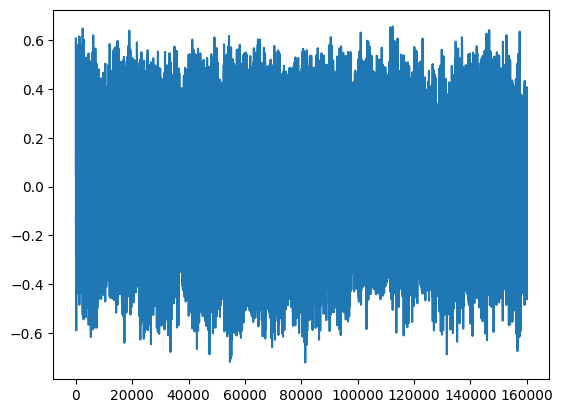

MFCCs: (13, 313)


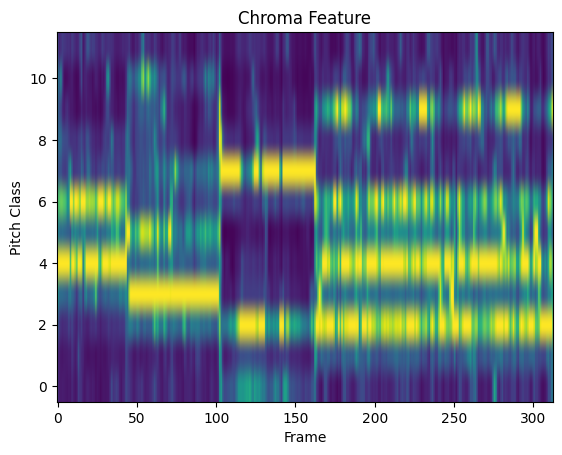

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/D2w3qHmJrdU_1.wav'>
File name: datashare/data_aug2/D2w3qHmJrdU_1.wav
Extracted file: <ExFileObject name='datashare/data_aug2/D2w3qHmJrdU_1.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.0


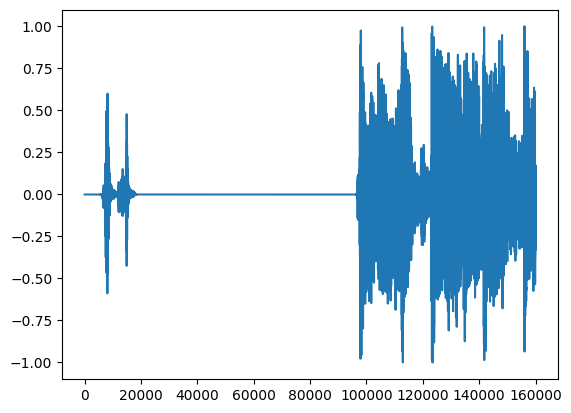

MFCCs: (13, 313)


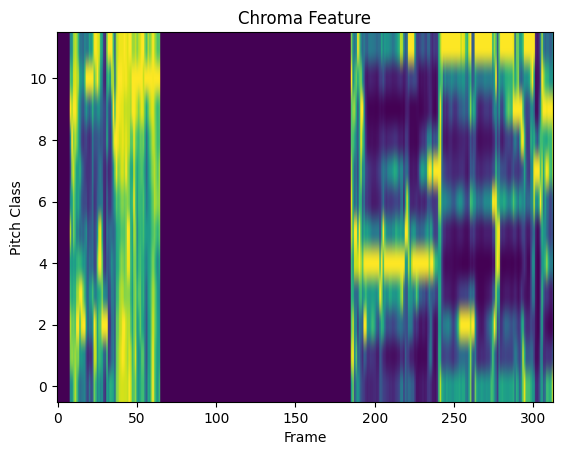

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/JIoA1KsfioQ_9.wav'>
File name: datashare/data_aug2/JIoA1KsfioQ_9.wav
Extracted file: <ExFileObject name='datashare/data_aug2/JIoA1KsfioQ_9.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: -0.1635437


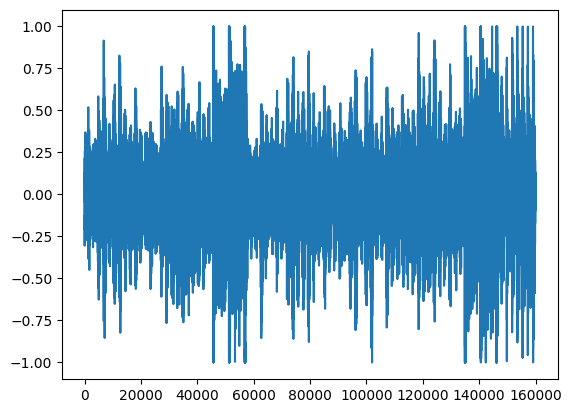

MFCCs: (13, 313)


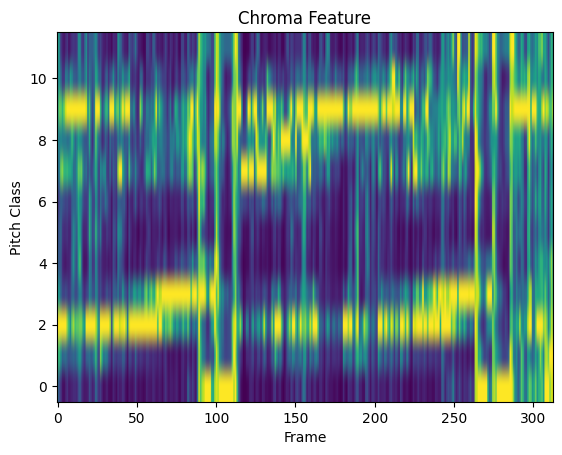

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/DP2vmsftZHY_8.wav'>
File name: datashare/data_aug2/DP2vmsftZHY_8.wav
Extracted file: <ExFileObject name='datashare/data_aug2/DP2vmsftZHY_8.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.11904907


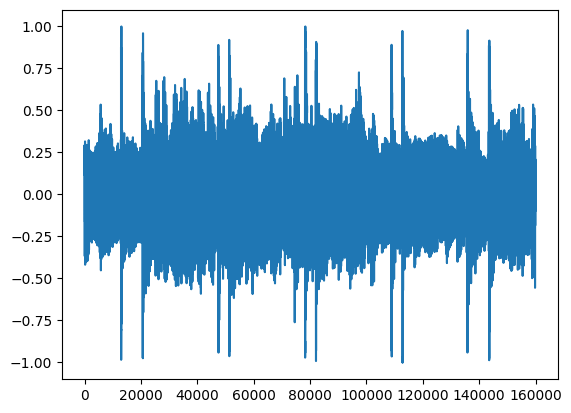

MFCCs: (13, 313)


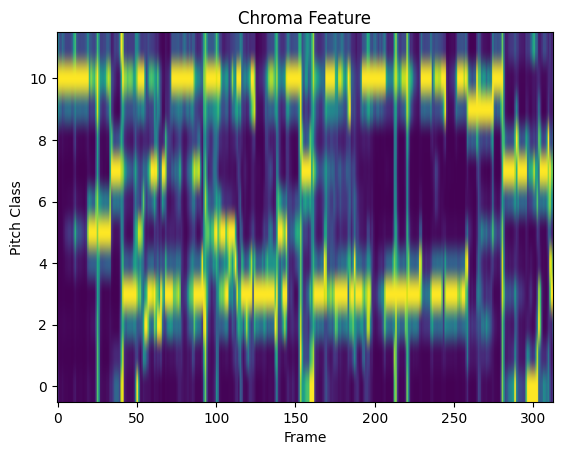

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/RdKQGIzKZ_c_3.wav'>
File name: datashare/data_aug2/RdKQGIzKZ_c_3.wav
Extracted file: <ExFileObject name='datashare/data_aug2/RdKQGIzKZ_c_3.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: -0.020996094


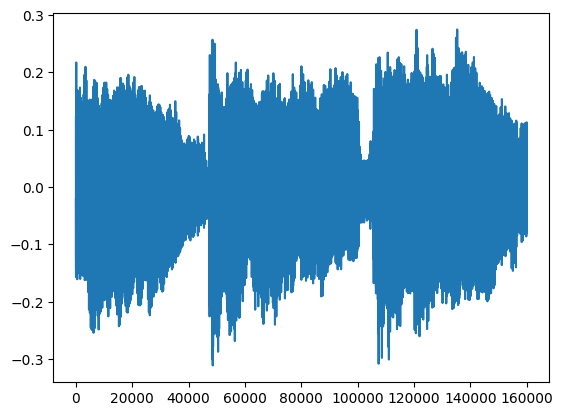

MFCCs: (13, 313)


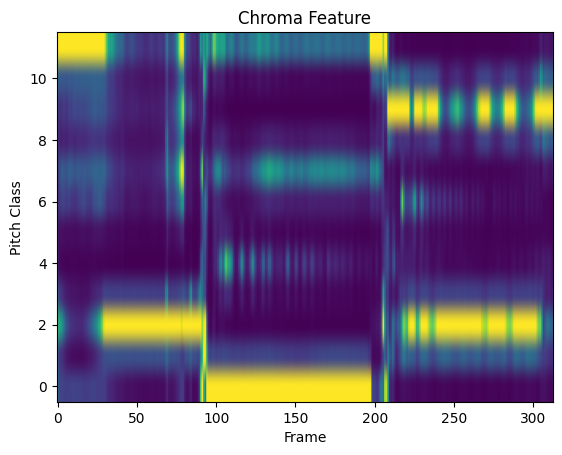

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/OiNlYrlJE4g_10.wav'>
File name: datashare/data_aug2/OiNlYrlJE4g_10.wav
Extracted file: <ExFileObject name='datashare/data_aug2/OiNlYrlJE4g_10.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: -0.039093018


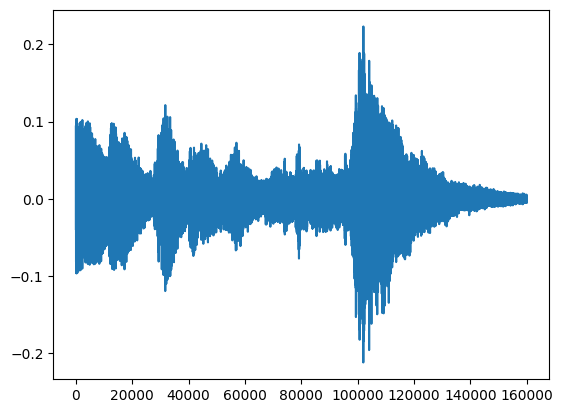

MFCCs: (13, 313)


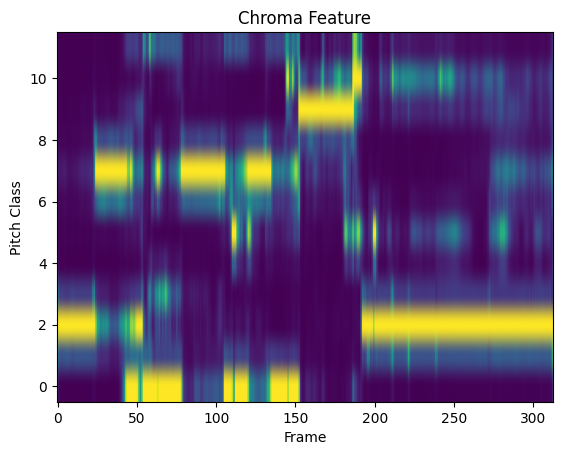

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/1FnT0RrfMEA_2.wav'>
File name: datashare/data_aug2/1FnT0RrfMEA_2.wav
Extracted file: <ExFileObject name='datashare/data_aug2/1FnT0RrfMEA_2.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.0154418945


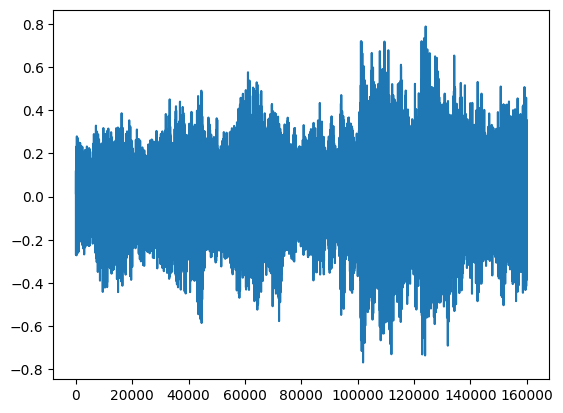

MFCCs: (13, 313)


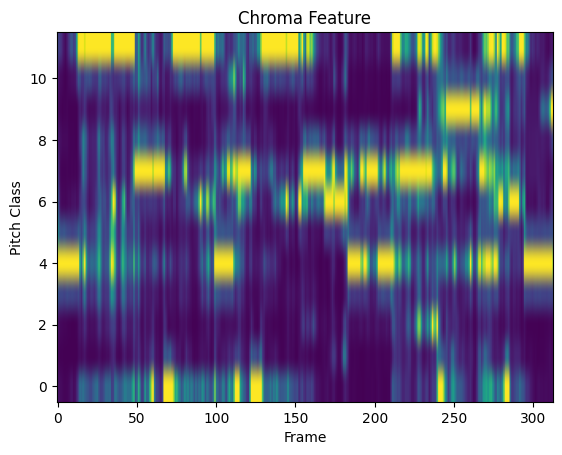

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/G6A9NKeK8ko_2.wav'>
File name: datashare/data_aug2/G6A9NKeK8ko_2.wav
Extracted file: <ExFileObject name='datashare/data_aug2/G6A9NKeK8ko_2.wav'> 

-----METADATA-----
Audio length: 134003 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (134003,)
audio_data element: -0.018218994


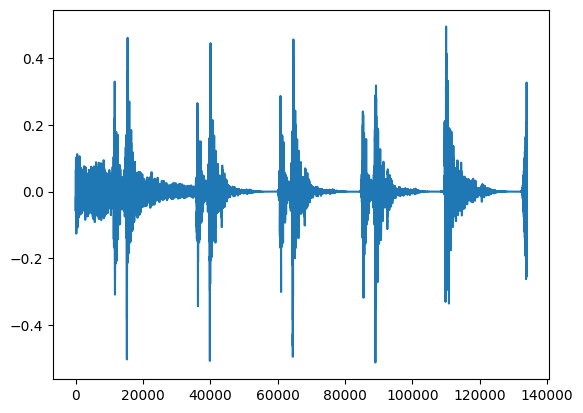

MFCCs: (13, 262)


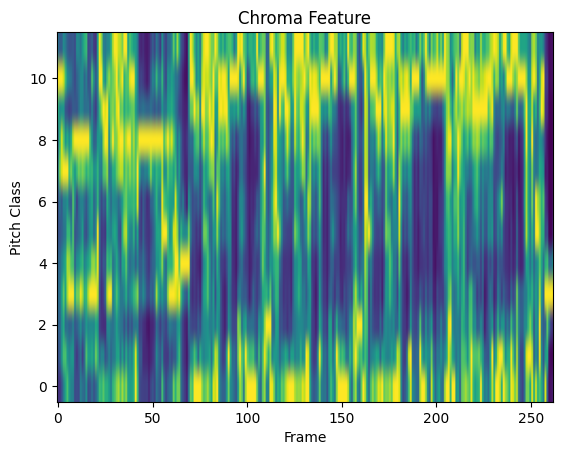

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/wxKtBDKasgM_1.wav'>
File name: datashare/data_aug2/wxKtBDKasgM_1.wav
Extracted file: <ExFileObject name='datashare/data_aug2/wxKtBDKasgM_1.wav'> 

-----METADATA-----
Audio length: 140246 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (140246,)
audio_data element: 0.058380127


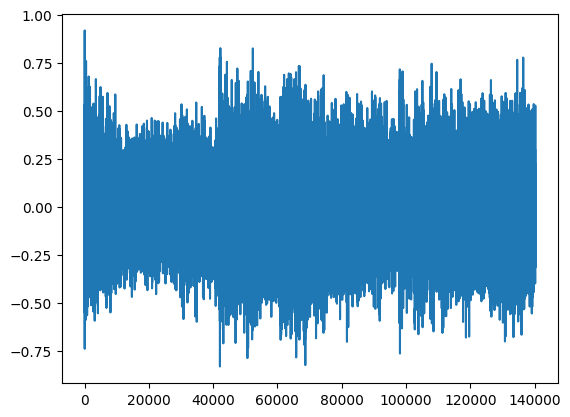

MFCCs: (13, 274)


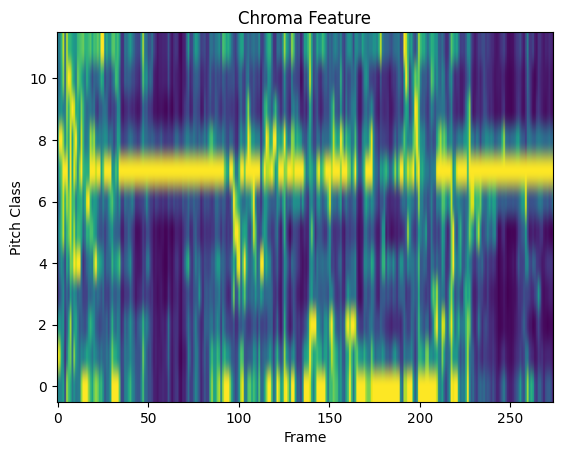

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/sfmAeijj5cM_8.wav'>
File name: datashare/data_aug2/sfmAeijj5cM_8.wav
Extracted file: <ExFileObject name='datashare/data_aug2/sfmAeijj5cM_8.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.042236328


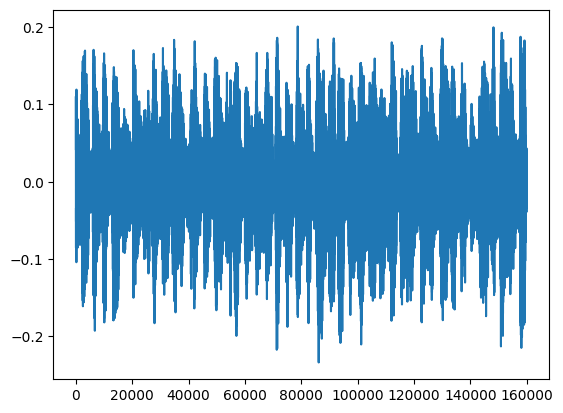

MFCCs: (13, 313)


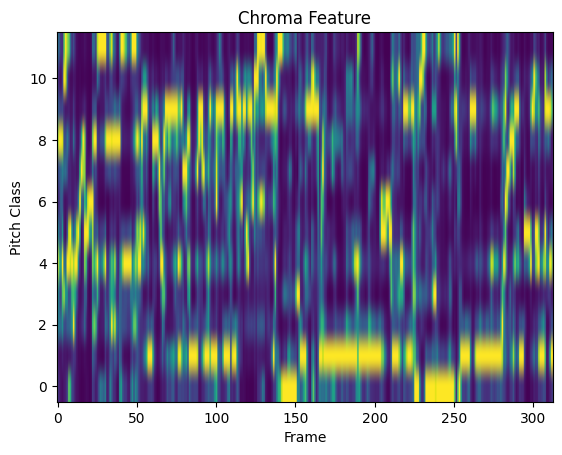

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/cFIZraIPAXE_4.wav'>
File name: datashare/data_aug2/cFIZraIPAXE_4.wav
Extracted file: <ExFileObject name='datashare/data_aug2/cFIZraIPAXE_4.wav'> 

-----METADATA-----
Audio length: 144602 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (144602,)
audio_data element: 0.15716553


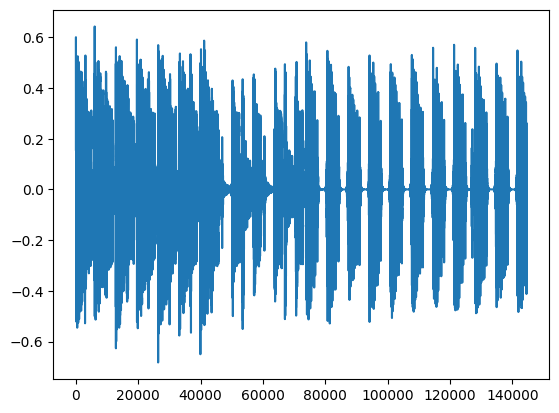

MFCCs: (13, 283)


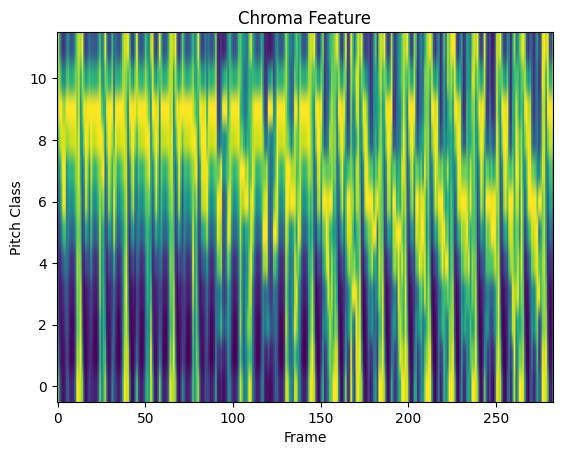

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/szWQPoOH2Rw_6.wav'>
File name: datashare/data_aug2/szWQPoOH2Rw_6.wav
Extracted file: <ExFileObject name='datashare/data_aug2/szWQPoOH2Rw_6.wav'> 

-----METADATA-----
Audio length: 159896 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (159896,)
audio_data element: 0.0


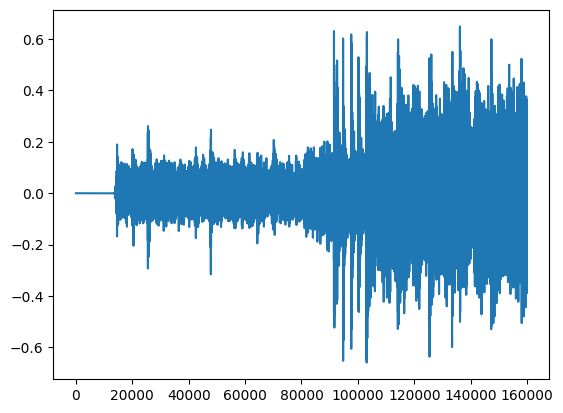

MFCCs: (13, 313)


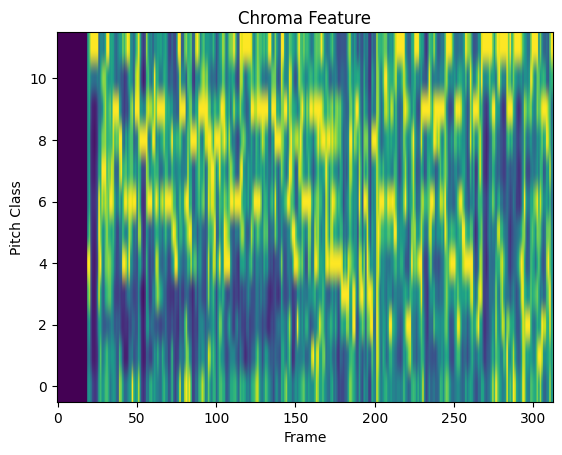

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/ap7xvCBtljs_8.wav'>
File name: datashare/data_aug2/ap7xvCBtljs_8.wav
Extracted file: <ExFileObject name='datashare/data_aug2/ap7xvCBtljs_8.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.050445557


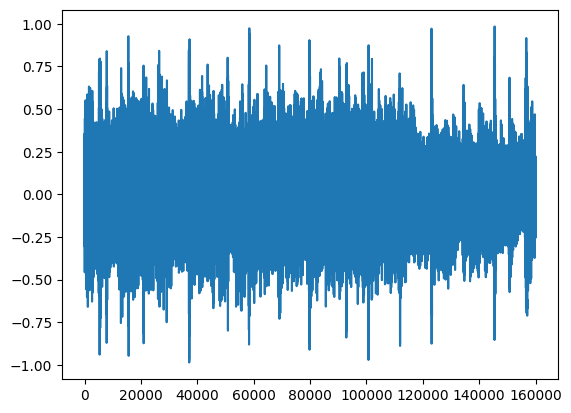

MFCCs: (13, 313)


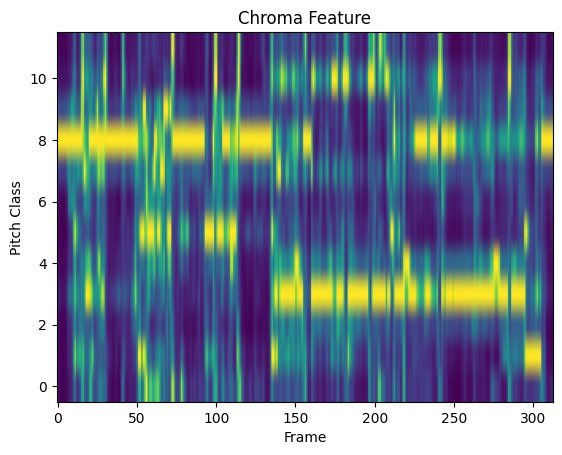

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/PE1ges9nn6A_4.wav'>
File name: datashare/data_aug2/PE1ges9nn6A_4.wav
Extracted file: <ExFileObject name='datashare/data_aug2/PE1ges9nn6A_4.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.056030273


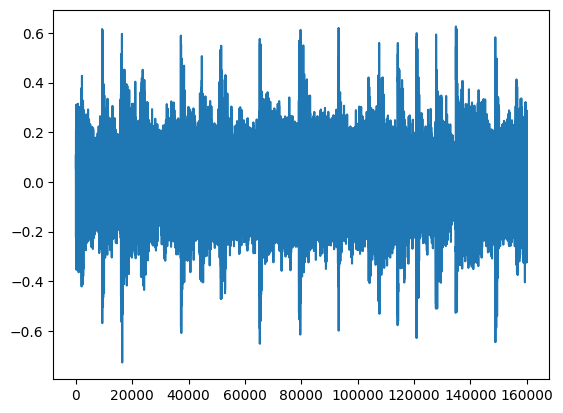

MFCCs: (13, 313)


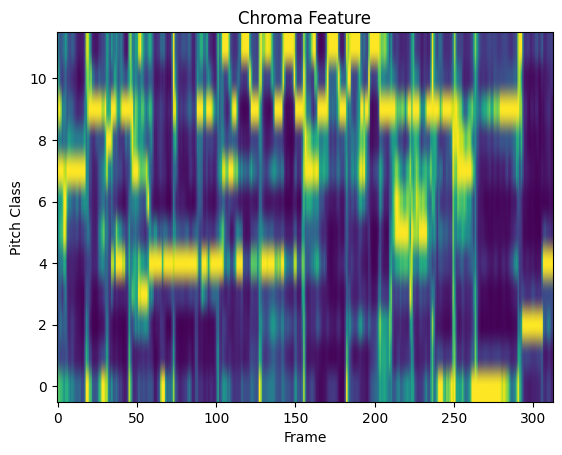

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/w-qG-P9E1U4_3.wav'>
File name: datashare/data_aug2/w-qG-P9E1U4_3.wav
Extracted file: <ExFileObject name='datashare/data_aug2/w-qG-P9E1U4_3.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.0019226074


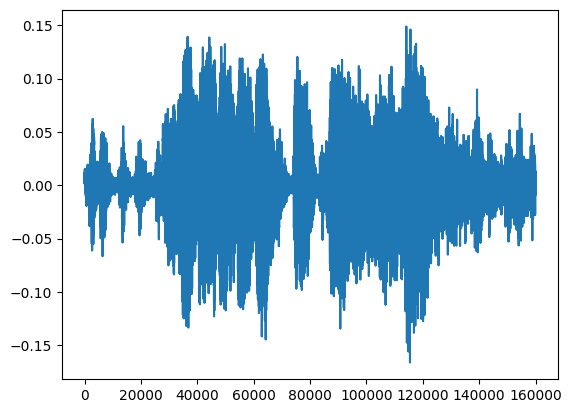

MFCCs: (13, 313)


KeyboardInterrupt: 

In [7]:
# get all audio files
open_audio_file()